# CLVmix - wine dataset

In [1]:
# disable warnings
from warnings import simplefilter, filterwarnings
simplefilter(action='ignore', category=FutureWarning)
filterwarnings("ignore")

## wine dataset

In [2]:
# poison dataset
from clustvartools.datasets import wine
data = wine.data
data.info()

<class 'pandas.DataFrame'>
Index: 21 entries, 2EL to T2
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Label                          21 non-null     str    
 1   Soil                           21 non-null     str    
 2   Odor.Intensity.before.shaking  21 non-null     float64
 3   Aroma.quality.before.shaking   21 non-null     float64
 4   Fruity.before.shaking          21 non-null     float64
 5   Flower.before.shaking          21 non-null     float64
 6   Spice.before.shaking           21 non-null     float64
 7   Visual.intensity               21 non-null     float64
 8   Nuance                         21 non-null     float64
 9   Surface.feeling                21 non-null     float64
 10  Odor.Intensity                 21 non-null     float64
 11  Quality.of.odour               21 non-null     float64
 12  Fruity                         21 non-null     float64
 13  Flower

## Instanciation and training

In [3]:
# instanciation
from clustvartools import CLVmix
clf = CLVmix(ncl=4)

### `fit` function

In [4]:
# fit function
clf.fit(data)

,ncl,4
,row_w,None
,sup_var,None
,tol,1e-07
Name,Type,Value
call_,call,call(Xtot= ... sup_var=None)
cluster_,cluster,cluster(summa...655 0.032240)
coef_,coef,coef(coef= ...NaN NaN)
var_,var,var(cluster=L...NaN NaN)


### `fit_transform` function

In [5]:
# fit_transform function - squared loadings
sqload = clf.fit_transform(data)
sqload

,1,2,3,4
Label,0.315981,0.112728,0.051477,0.023257
Soil,0.695897,0.292011,0.436815,0.486931
Odor.Intensity.before.shaking,0.799702,0.394922,0.010313,0.029591
Aroma.quality.before.shaking,0.101264,0.549332,0.017251,0.605694
Fruity.before.shaking,0.025288,0.337169,0.000707,0.521935
Flower.before.shaking,0.000678,0.139178,0.815526,0.204273
Spice.before.shaking,0.481284,0.033383,0.133814,0.106165
Visual.intensity,0.335235,0.860970,0.041314,0.413704
Nuance,0.307723,0.840721,0.031008,0.393507
Surface.feeling,0.225905,0.900829,0.062470,0.642039


### `transform` function

In [6]:
# transform function
sqload = clf.transform(data)
sqload

,1,2,3,4
Label,0.315981,0.112728,0.051477,0.023257
Soil,0.695897,0.292011,0.436815,0.486931
Odor.Intensity.before.shaking,0.799702,0.394922,0.010313,0.029591
Aroma.quality.before.shaking,0.101264,0.549332,0.017251,0.605694
Fruity.before.shaking,0.025288,0.337169,0.000707,0.521935
Flower.before.shaking,0.000678,0.139178,0.815526,0.204273
Spice.before.shaking,0.481284,0.033383,0.133814,0.106165
Visual.intensity,0.335235,0.860970,0.041314,0.413704
Nuance,0.307723,0.840721,0.031008,0.393507
Surface.feeling,0.225905,0.900829,0.062470,0.642039


### `fit_predict` function

In [7]:
# fit_predict function
prediction = clf.fit_predict(data)
prediction.to_frame()

,cluster
Label,1
Soil,1
Odor.Intensity.before.shaking,1
Aroma.quality.before.shaking,4
Fruity.before.shaking,4
Flower.before.shaking,3
Spice.before.shaking,1
Visual.intensity,2
Nuance,2
Surface.feeling,2


### `predict` function

In [8]:
# predict function
prediction = clf.predict(data)
prediction.to_frame()

,cluster
Label,1
Soil,1
Odor.Intensity.before.shaking,1
Aroma.quality.before.shaking,4
Fruity.before.shaking,4
Flower.before.shaking,3
Spice.before.shaking,1
Visual.intensity,2
Nuance,2
Surface.feeling,2


In [9]:
# attributes
from clustvartools import sprintf
sprintf(clf)


**Clustering of Variables - CLVmix**

*The results are available in the following objects:

name       description
---------  -------------------------
.call_     summary called parameters
.cluster_  results for clusters
.coef_     Coefficients
.var_      results for variables



## Cluster informations

In [10]:
# clusters informations
cluster = clf.cluster_
cluster._fields

('summary', 'princomps', 'cor', 'cortest')

### Cluster summary

In [11]:
# cluster summary
cluster_summary = clf.cluster_.summary
cluster_summary

,Cluster,Members,Variation Explained,Proportion Explained
0,1,8,4.455192,0.405017
1,2,9,7.331017,0.814557
2,3,3,1.922301,0.640767
3,4,11,8.450257,0.768205


### Inter-cluster correlations

In [12]:
# inter-cluster correlations
icor = cluster.cor
icor

,1,2,3,4
1,1.000000,0.575031,-0.210318,0.005023
2,0.575031,1.000000,0.271708,-0.769708
3,-0.210318,0.271708,1.000000,-0.468363
4,0.005023,-0.769708,-0.468363,1.000000


### Latent variables

In [13]:
# latent variables
princomps = cluster.princomps
princomps.head()

,1,2,3,4
2EL,0.748330,0.392284,-2.203943,0.420916
1CHA,2.002574,2.983682,-2.729808,-2.342231
1FON,1.686197,1.663831,-0.032596,-0.176939
1VAU,1.305893,5.592410,2.372847,-7.065817
1DAM,-1.376613,-2.768105,-0.435153,3.906203


## Coefficients

In [14]:
# coefficients
coeffs = clf.coef_
coeffs._fields

('coef', 'coef_std')

### Coefficients of linear combinations

In [15]:
# coefficients of linear combinations
coef = coeffs.coef
coef

,1,2,3,4
const,25.101345,33.200245,14.958607,-28.247954
Odor.Intensity.before.shaking,-1.499851,NaN,NaN,NaN
Aroma.quality.before.shaking,NaN,NaN,NaN,1.334072
Fruity.before.shaking,NaN,NaN,NaN,1.266832
Flower.before.shaking,NaN,NaN,-4.647976,NaN
Spice.before.shaking,-1.405280,NaN,NaN,NaN
Visual.intensity,NaN,-0.639098,NaN,NaN
Nuance,NaN,-0.666374,NaN,NaN
Surface.feeling,NaN,-1.283648,NaN,NaN
Odor.Intensity,-2.118743,NaN,NaN,NaN


### Standardized scoring coefficients

In [16]:
# standardized scoring coefficients
coef_std = coeffs.coef_std
coef_std

,1,2,3,4
Odor.Intensity.before.shaking,-0.200723,NaN,NaN,NaN
Aroma.quality.before.shaking,NaN,NaN,NaN,0.092099
Fruity.before.shaking,NaN,NaN,NaN,0.085495
Flower.before.shaking,NaN,NaN,-0.469783,NaN
Spice.before.shaking,-0.155716,NaN,NaN,NaN
Visual.intensity,NaN,-0.126570,NaN,NaN
Nuance,NaN,-0.125072,NaN,NaN
Surface.feeling,NaN,-0.129466,NaN,NaN
Odor.Intensity,-0.196400,NaN,NaN,NaN
Quality.of.odour,NaN,NaN,NaN,0.105453


## Variables informations

In [17]:
# variables informations
var_ = clf.var_
var_._fields

('cluster', 'cor', 'cortest', 'sqload', 'member', 'sim', 'loadings')

### Variables loadings (=eigenvectors)

In [18]:
# variables loadings
var_.loadings

,1,2,3,4
Odor.Intensity.before.shaking,-0.423673,NaN,NaN,NaN
Aroma.quality.before.shaking,NaN,NaN,NaN,0.267727
Fruity.before.shaking,NaN,NaN,NaN,0.248527
Flower.before.shaking,NaN,NaN,-0.651341,NaN
Spice.before.shaking,-0.328676,NaN,NaN,NaN
Visual.intensity,NaN,-0.342698,NaN,NaN
Nuance,NaN,-0.338644,NaN,NaN
Surface.feeling,NaN,-0.350541,NaN,NaN
Odor.Intensity,-0.414548,NaN,NaN,NaN
Quality.of.odour,NaN,NaN,NaN,0.306546


### Cluster correlations - Structure

In [19]:
# cluster correlation
var_.cor

,1,2,3,4
Odor.Intensity.before.shaking,-0.894261,-0.628428,0.101553,0.172019
Aroma.quality.before.shaking,-0.318219,-0.741169,-0.131342,0.778264
Fruity.before.shaking,-0.159021,-0.580663,-0.026595,0.722451
Flower.before.shaking,0.026039,-0.373066,-0.903065,0.451966
Spice.before.shaking,-0.693746,-0.182711,0.365806,-0.325829
Visual.intensity,-0.578995,-0.927885,-0.203258,0.643198
Nuance,-0.554728,-0.916909,-0.176092,0.627301
Surface.feeling,-0.475295,-0.949120,-0.249941,0.801273
Odor.Intensity,-0.875000,-0.692811,-0.097809,0.238123
Quality.of.odour,0.016339,-0.709287,-0.287855,0.891109


### Cluster relationship with variables

In [20]:
# cluster relationship
var_.cortest

,variable,cluster,r,r**2,t,Pr(>|t|)
0,Odor.Intensity.before.shaking,1,-0.894261,0.799702,-8.709689,4.637314e-08
1,Odor.Intensity.before.shaking,2,-0.628428,0.394922,-3.521493,2.281283e-03
2,Odor.Intensity.before.shaking,3,0.101553,0.010313,0.444959,6.613768e-01
3,Odor.Intensity.before.shaking,4,0.172019,0.029591,0.761160,4.559055e-01
4,Aroma.quality.before.shaking,1,-0.318219,0.101264,-1.463145,1.597748e-01
...,...,...,...,...,...,...
111,Overall.quality,4,0.919918,0.846249,10.226281,3.665831e-09
112,Typical,1,0.054233,0.002941,0.236743,8.153896e-01
113,Typical,2,-0.700539,0.490755,-4.279031,4.052875e-04
114,Typical,3,-0.512958,0.263126,-2.604726,1.740872e-02


### Cluster squared Loadings

In [21]:
# squared loadings
var_.sqload

,1,2,3,4
Label,0.315981,0.112728,0.051477,0.023257
Soil,0.695897,0.292011,0.436815,0.486931
Odor.Intensity.before.shaking,0.799702,0.394922,0.010313,0.029591
Aroma.quality.before.shaking,0.101264,0.549332,0.017251,0.605694
Fruity.before.shaking,0.025288,0.337169,0.000707,0.521935
Flower.before.shaking,0.000678,0.139178,0.815526,0.204273
Spice.before.shaking,0.481284,0.033383,0.133814,0.106165
Visual.intensity,0.335235,0.860970,0.041314,0.413704
Nuance,0.307723,0.840721,0.031008,0.393507
Surface.feeling,0.225905,0.900829,0.062470,0.642039


### Cluster member

In [22]:
# cluster member
var_.member.sort_values(by=["Cluster","Variable"])

,Variable,Cluster,Own Cluster,Next Closest,1 - R**2 Ratio
26,Bitterness,1,0.65023,0.235918,0.457765
0,Label,1,0.315981,0.112728,0.770924
10,Odor.Intensity,1,0.765626,0.479988,0.450709
2,Odor.Intensity.before.shaking,1,0.799702,0.394922,0.331028
16,Phenolic,1,0.28354,0.176697,0.870226
1,Soil,1,0.695897,0.486931,0.592713
14,Spice,1,0.462932,0.157617,0.637558
6,Spice.before.shaking,1,0.481284,0.133814,0.598851
23,Alcohol,2,0.683187,0.357094,0.492783
17,Aroma.intensity,2,0.752257,0.589654,0.603742


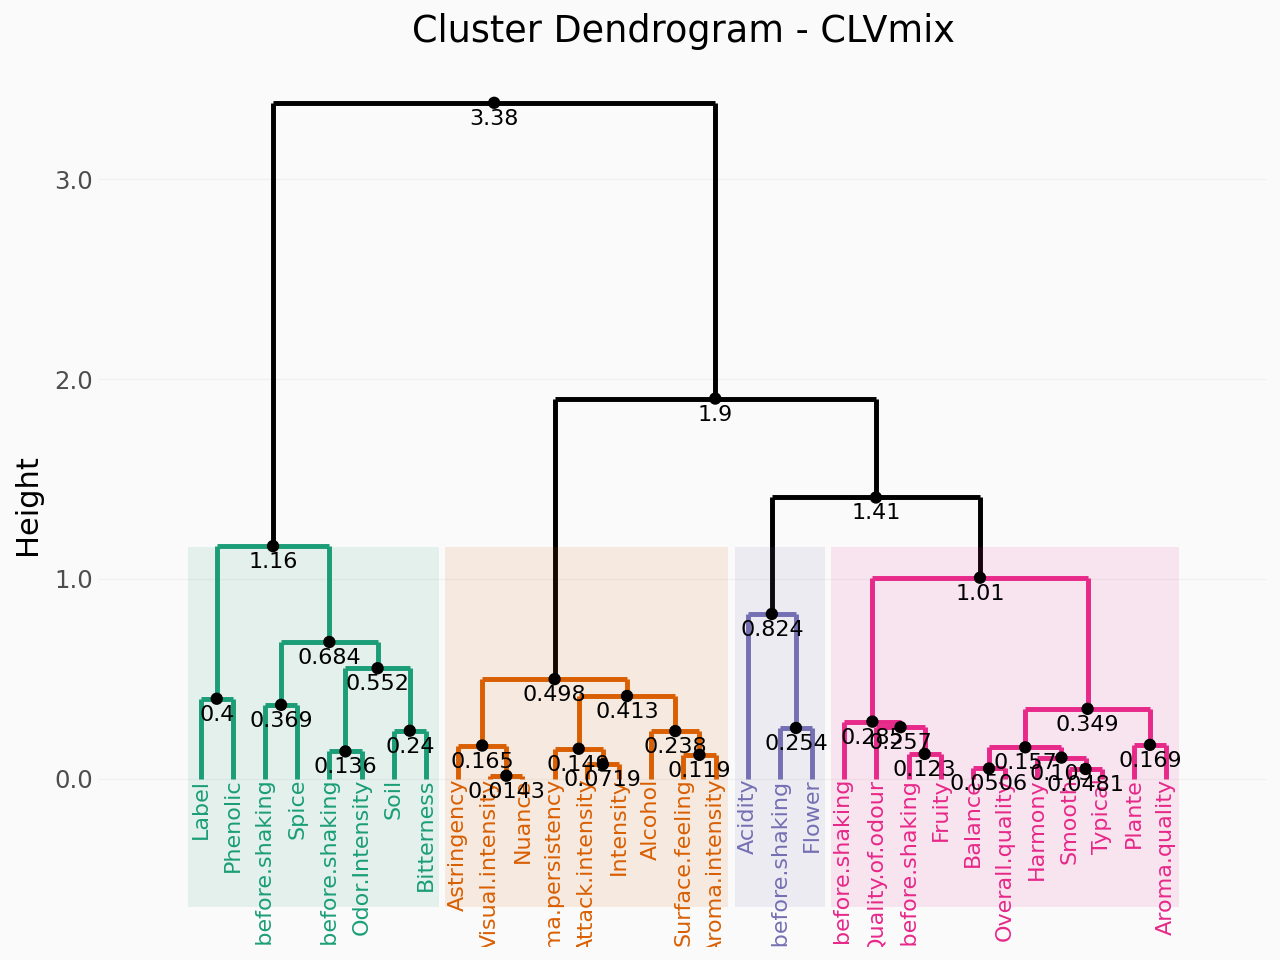

None


In [23]:
# dendrogram
from clustvartools import fviz_dend, fviz_height
p = fviz_dend(obj=clf,
              rect=True,
              rect_fill=True,
              color_labels_by_cluster=True,
              text_size=8,
              text_height=True,
              nudge_y=-0.03)
print(p.show())

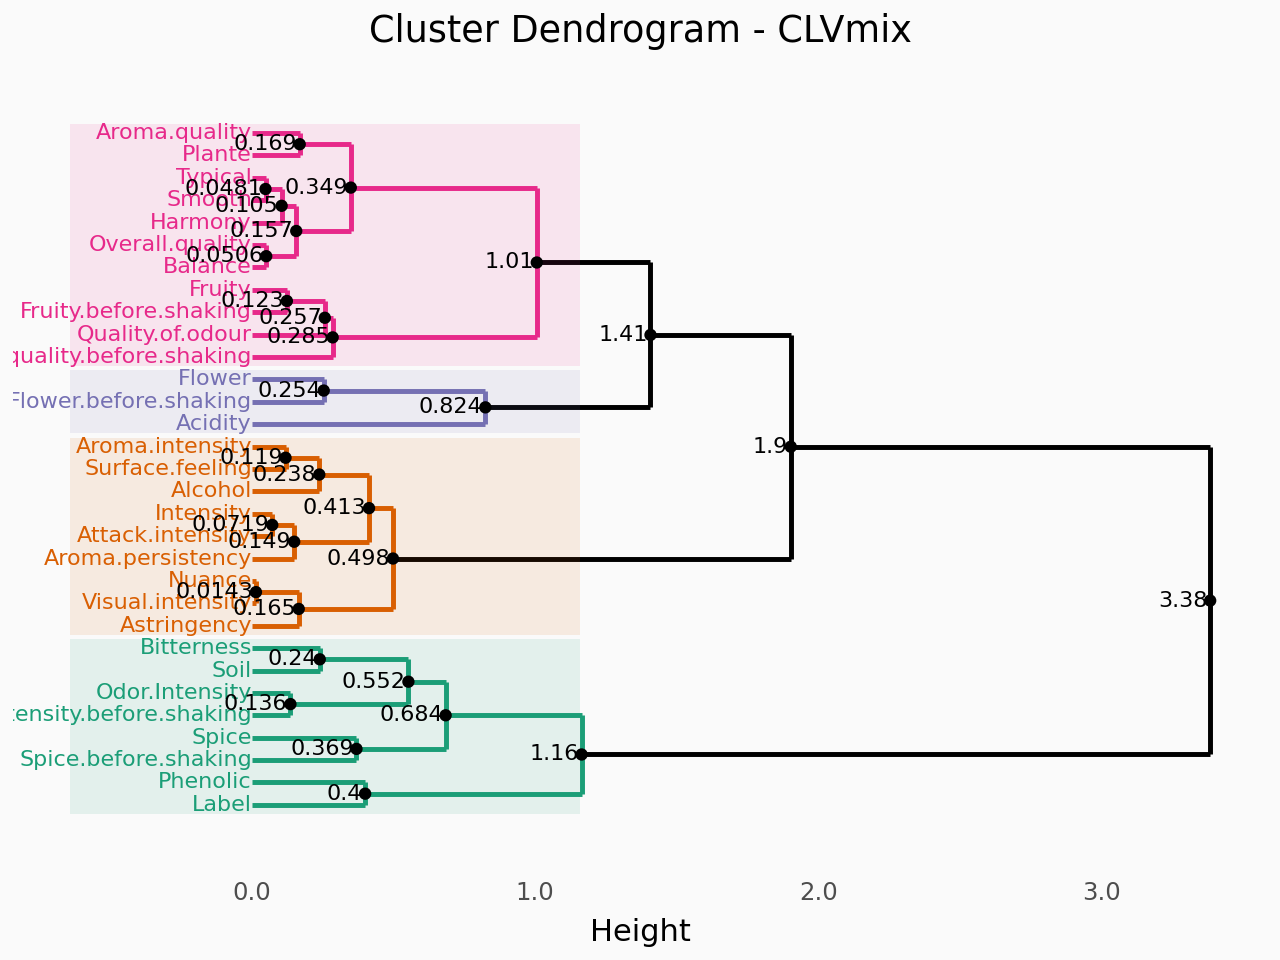

None


In [24]:
# horizon 
p = fviz_dend(obj=clf,
              horiz=True,
              rect=True,
              rect_fill=True,
              color_labels_by_cluster=True,
              text_size=8,
              text_height=True,
              nudge_x=-0.01)
print(p.show())

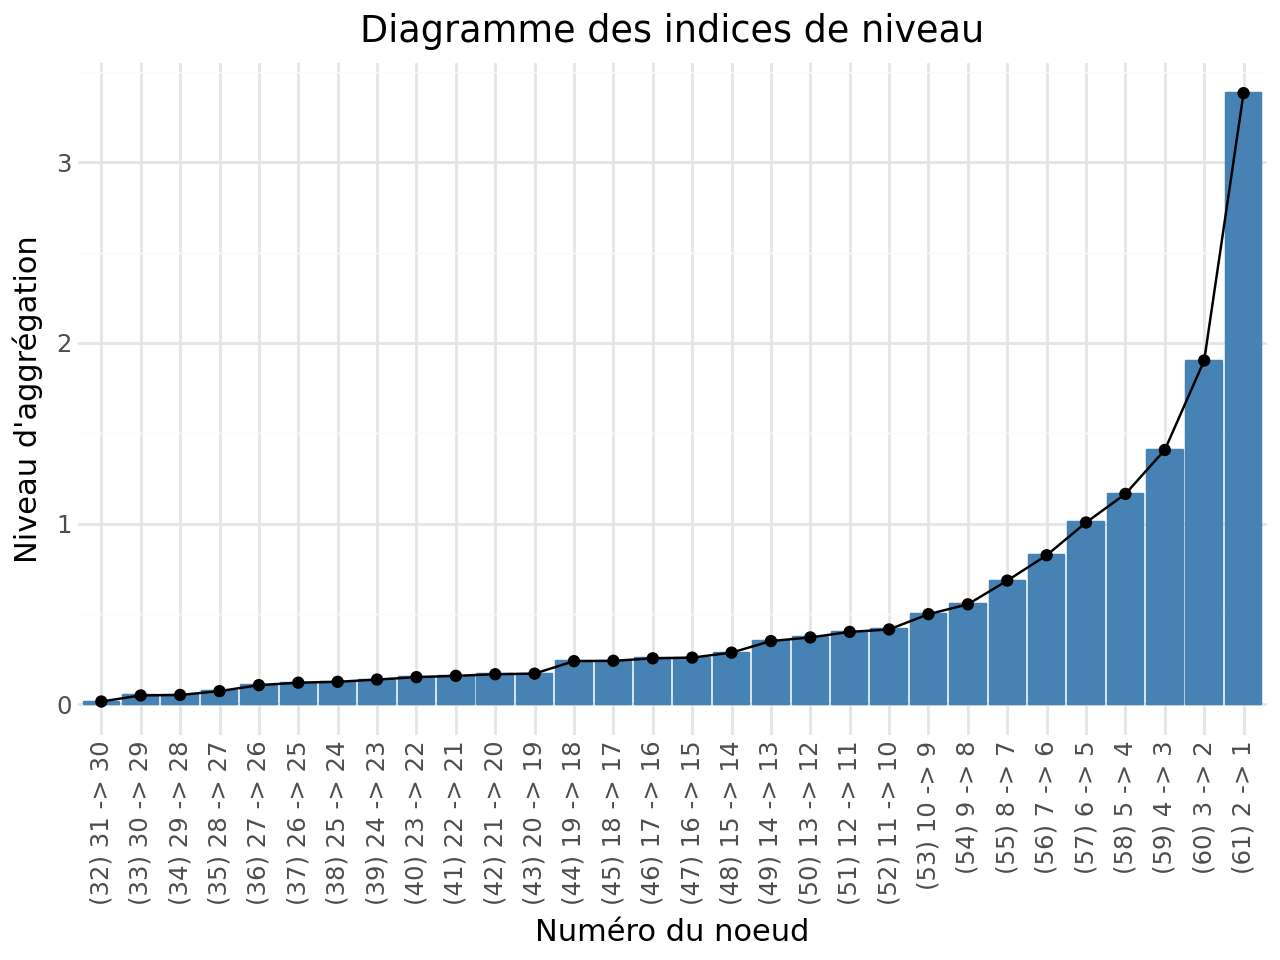

None


In [25]:
# graph of height
p = fviz_height(clf)
print(p.show())

## Summary

In [26]:
# summary
from clustvartools import summary
summary(clf)

                     Clustering of Variables - CLVmix Results                     

Cluster Summary for 4 Clusters:
  Cluster  Members  Variation Explained  Proportion Explained
0       1        8             4.455192              0.405017
1       2        9             7.331017              0.814557
2       3        3             1.922301              0.640767
3       4       11             8.450257              0.768205

Inter-cluster Correlations:
          1         2         3         4
1  1.000000  0.575031 -0.210318  0.005023
2  0.575031  1.000000  0.271708 -0.769708
3 -0.210318  0.271708  1.000000 -0.468363
4  0.005023 -0.769708 -0.468363  1.000000

Cluster Squared Loadings:
                                    1       2       3       4
Label                          0.3160  0.1127  0.0515  0.0233
Soil                           0.6959  0.2920  0.4368  0.4869
Odor.Intensity.before.shaking  0.7997  0.3949  0.0103  0.0296
Aroma.quality.before.shaking   0.1013  0.5493  0.0173  0.605

In [27]:
# summary with detailed
summary(clf,detailed=True)

                     Clustering of Variables - CLVmix Results                     

Cluster Summary for 4 Clusters:
  Cluster  Members  Variation Explained  Proportion Explained
0       1        8             4.455192              0.405017
1       2        9             7.331017              0.814557
2       3        3             1.922301              0.640767
3       4       11             8.450257              0.768205

Inter-cluster Correlations:
          1         2         3         4
1  1.000000  0.575031 -0.210318  0.005023
2  0.575031  1.000000  0.271708 -0.769708
3 -0.210318  0.271708  1.000000 -0.468363
4  0.005023 -0.769708 -0.468363  1.000000

Linear coefficients:
                                       1          2          3          4
const                          25.101345  33.200245  14.958607 -28.247954
Odor.Intensity.before.shaking  -1.499851        NaN        NaN        NaN
Aroma.quality.before.shaking         NaN        NaN        NaN   1.334072
Fruity.before.sha

In [28]:
# markdown formatting
summary(clf,to_markdown=True)

                     Clustering of Variables - CLVmix Results                     

Cluster Summary for 4 Clusters:
      Cluster    Members    Variation Explained    Proportion Explained
--  ---------  ---------  ---------------------  ----------------------
 0          1          8                4.45519                0.405017
 1          2          9                7.33102                0.814557
 2          3          3                1.9223                 0.640767
 3          4         11                8.45026                0.768205

Inter-cluster Correlations:
              1          2          3            4
--  -----------  ---------  ---------  -----------
 1   1            0.575031  -0.210318   0.00502329
 2   0.575031     1          0.271708  -0.769708
 3  -0.210318     0.271708   1         -0.468363
 4   0.00502329  -0.769708  -0.468363   1

Cluster Squared Loadings:
                                    1       2       3       4
-----------------------------  ------  --

In [29]:
# markdown formatting
summary(clf,detailed=True,to_markdown=True)

                     Clustering of Variables - CLVmix Results                     

Cluster Summary for 4 Clusters:
      Cluster    Members    Variation Explained    Proportion Explained
--  ---------  ---------  ---------------------  ----------------------
 0          1          8                4.45519                0.405017
 1          2          9                7.33102                0.814557
 2          3          3                1.9223                 0.640767
 3          4         11                8.45026                0.768205

Inter-cluster Correlations:
              1          2          3            4
--  -----------  ---------  ---------  -----------
 1   1            0.575031  -0.210318   0.00502329
 2   0.575031     1          0.271708  -0.769708
 3  -0.210318     0.271708   1         -0.468363
 4   0.00502329  -0.769708  -0.468363   1

Linear coefficients:
                                         1           2          3           4
----------------------------- 